# Cairn: Teaching a Small Model to Triage Like a Large One

**Author:** Rahul Kumar | **Hardware:** 1x GH200 96GB (Lambda) | **Framework:** [Unsloth](https://github.com/unslothai/unsloth)

### The Problem
In disaster zones, there is no internet. CHWs face life-or-death triage with zero AI support. LLMs detect critical patients at 87.8% accuracy vs nurses at 32.7% ([Arslan et al., AJEM 2025](https://doi.org/10.1016/j.ajem.2024.12.001)). But base models **over-triage everything as RED** — paper cuts become emergencies.

### Our Fix: Teacher-Student Distillation
Use Gemma 4 26B-A4B (teacher) to label 75 clinical scenarios, then fine-tune E4B (student) on those labels. Narrow skill transfer — we teach calibration, not medicine.

### This Notebook
1. Load E4B via `FastVisionModel` (16-bit) + LoRA
2. Eval base model (expect ~50%)
3. SFT on 130 distilled examples
4. Eval fine-tuned (expect ~85%+)
5. Export GGUF for Ollama
6. Push to HuggingFace

**CRITICAL**: Uses `FastVisionModel` + `load_in_4bit=False` — the official Unsloth Gemma 4 pattern. Previous attempts with `FastLanguageModel` + 4-bit caused GGUF export failures.

## Step 1: Install

In [1]:
!pip install torch==2.10.0+cu128 --index-url https://download.pytorch.org/whl/cu128

Defaulting to user installation because normal site-packages is not writeable
Looking in indexes: https://download.pytorch.org/whl/cu128
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.1/43.1 MB 232.7 MB/s eta 0:00:00a 0:00:01
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 965.3/965.3 kB 129.5 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.5/9.5 MB 236.9 MB/s eta 0:00:00a 0:00:01
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 705.0/705.0 MB 112.4 MB/s eta 0:00:0000:0100:01
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 590.5/590.5 MB 98.2 MB/s eta 0:00:0000:0100:01
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 193.1/193.1 MB 182.9 MB/s eta 0:00:0000:0100:01
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 63.6/63.6 MB 186.6 MB/s eta 0:00:00a 0:00:01
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 267.2/267.2 MB 160.7 MB/s eta 0:00:0000:0100:01
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 288.1/288.1 MB 154.1 MB/s eta 0:00:0000:0100:01
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 283.8/283.8 MB 

In [2]:
%%capture
# IMPORTANT: Do NOT upgrade torch/torchvision/triton — Lambda's pre-installed CUDA stack works.
# Only install Unsloth + training deps on top.
!pip install --no-deps unsloth unsloth_zoo
!pip install --no-deps trl peft accelerate bitsandbytes
!pip install --no-deps huggingface_hub datasets
# Ensure transformers >= 5.5.0 (Gemma 4 requirement) without touching torch
!pip install --no-deps "transformers>=5.5.0" tokenizers

In [3]:
# If torch.cuda is not available after install, restart the kernel once and re-run from this cell
import torch
if not torch.cuda.is_available():
    print("CUDA not detected. This usually means pip upgraded torch and broke the CUDA build.")
    print("Fix: Restart kernel (Kernel → Restart) then run ALL cells again.")
    print("If it persists, run: !pip install torch==2.10.0+cu128 --index-url https://download.pytorch.org/whl/cu128")
else:
    print(f"GPU: {torch.cuda.get_device_name(0)} ({torch.cuda.get_device_properties(0).total_memory/1024**3:.0f} GB)")
    print(f"PyTorch: {torch.__version__}, CUDA: {torch.version.cuda}")

GPU: NVIDIA GH200 480GB (94 GB)
PyTorch: 2.10.0+cu128, CUDA: 12.8


## Step 2: Load Base Model

**`FastVisionModel`** (not `FastLanguageModel`) — E4B is multimodal.  
**`load_in_4bit=False`** — 16-bit LoRA. Required for working GGUF export.  
**`unsloth/gemma-4-E4B-it`** — official Unsloth model ID for 16-bit loading.

**GH200 note**: FlashAttention2 on GH200 doesn't support Gemma 4's head dimension (>256). We set `ATTN_BACKEND=eager` as a safety fallback. With 96GB VRAM, the 16-bit model (~16GB) + training (~10GB) + GGUF export fit comfortably.

In [4]:
HF_TOKEN="YOUR_HF_TOKEN_HERE"

In [5]:
import os
os.environ["HF_HUB_DISABLE_TELEMETRY"] = "1"
os.environ["UNSLOTH_DISABLE_STATISTICS"] = "1"

# GH200 FA2 workaround: Gemma 4's head dimension (>256) isn't supported by FA2 on GH200.
# Unsloth usually handles this, but we set these as safety fallback.
os.environ["ATTN_BACKEND"] = "eager"
os.environ["TRANSFORMERS_NO_FLASH_ATTENTION"] = "1"

from huggingface_hub import login
login(token=HF_TOKEN)

from unsloth import FastVisionModel  # NOT FastLanguageModel
import torch

max_seq_length = 2048

model, tokenizer = FastVisionModel.from_pretrained(
    model_name="unsloth/gemma-4-E4B-it",  # NOT the -bnb-4bit variant
    max_seq_length=max_seq_length,
    load_in_4bit=False,  # 16-bit — required for GGUF export
    token=HF_TOKEN,
)
print(f"Model: {model.num_parameters():,} params")
print(f"GPU: {torch.cuda.memory_allocated()/1024**3:.1f} GB / {torch.cuda.get_device_properties(0).total_memory/1024**3:.0f} GB")

/home/ubuntu/.local/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


🦥 Unsloth: Will patch your computer to enable 2x faster free finetuning.
Unsloth: Your Flash Attention 2 installation seems to be broken. Using Xformers instead. No performance changes will be seen.
🦥 Unsloth Zoo will now patch everything to make training faster!
==((====))==  Unsloth 2026.4.6: Fast Gemma4 patching. Transformers: 5.5.0.
   \\   /|    NVIDIA GH200 480GB. Num GPUs = 1. Max memory: 94.5 GB. Platform: Linux.
O^O/ \_/ \    Torch: 2.10.0+cu128. CUDA: 9.0. CUDA Toolkit: 12.8. Triton: 3.6.0
\        /    Bfloat16 = TRUE. FA [Xformers = None. FA2 = False]
 "-____-"     Free license: http://github.com/unslothai/unsloth
Unsloth: Fast downloading is enabled - ignore downloading bars which are red colored!
Unsloth: QLoRA and full finetuning all not selected. Switching to 16bit LoRA.


Loading weights: 100%|██████████| 2130/2130 [00:01<00:00, 1218.85it/s]


Model: 7,996,156,448 params
GPU: 14.9 GB / 94 GB


## Step 3: Add LoRA

Rank 32, alpha 64 (2x rank for faster convergence — Unsloth recommendation). All attention + MLP.

In [6]:
model = FastVisionModel.get_peft_model(
    model,
    r=32,
    target_modules=["q_proj", "k_proj", "v_proj", "o_proj",
                    "gate_proj", "up_proj", "down_proj"],
    lora_alpha=64,  # 2x rank — Unsloth's recommended setting
    lora_dropout=0,
    bias="none",
    use_gradient_checkpointing="unsloth",
    random_state=3407,
)
model.print_trainable_parameters()
print(f"GPU: {torch.cuda.memory_allocated()/1024**3:.1f} GB")

[unsloth_zoo.log|WARNING]Unsloth: Failed to register input-embedding hook for `model.base_model.model.model.audio_tower`: `get_input_embeddings` not auto‑handled for Gemma4AudioModel; please override in the subclass.. Falling back to pre-forward hook.


trainable params: 84,803,584 || all params: 8,080,960,032 || trainable%: 1.0494
GPU: 15.2 GB


## Step 4: Load Training Data

130 distilled examples: 75 scenarios (WHO ETAT + ESI) x 26B-A4B teacher + vitals augmentation.  
Distribution: 38 RED / 40 YELLOW / 52 GREEN (GREEN-weighted to fix over-triage).

In [7]:
import json
from datasets import Dataset
from collections import Counter

rows = [json.loads(l) for l in open("./cairn_distillation_train.jsonl")]
levels = Counter(r["expected_level"] for r in rows)
print(f"Loaded {len(rows)} examples: RED={levels['RED']}, YELLOW={levels['YELLOW']}, GREEN={levels['GREEN']}")

def format_conversation(row):
    messages = [{"role": m["role"], "content": [{"type": "text", "text": m["content"]}]}
               for m in row["conversations"]]
    return {"text": tokenizer.apply_chat_template(messages, tokenize=False, add_generation_prompt=False)}

dataset = Dataset.from_list(rows).map(format_conversation)
print(f"Formatted {len(dataset)} examples")

Loaded 130 examples: RED=38, YELLOW=40, GREEN=52


Map: 100%|██████████| 130/130 [00:00<00:00, 1430.10 examples/s]

Formatted 130 examples


## Step 5: Evaluate Base Model

20 cases (15 held-out + 5 calibration). Expected: ~50% — RED 100%, GREEN/YELLOW over-triaged.

In [8]:
import re

def extract_triage_level(text):
    text_upper = text.upper()
    for p in [r"TRIAGE\s*(?:LEVEL)?[:\s]*\*{0,2}\s*(RED|YELLOW|GREEN)", r"LEVEL[:\s]*\*{0,2}\s*(RED|YELLOW|GREEN)"]:
        m = re.search(p, text_upper)
        if m: return m.group(1)
    for l in ["RED", "YELLOW", "GREEN"]:
        if re.search(rf"\b{l}\b", text_upper): return l
    return "YELLOW"

held_out = [
    {"desc": "19yo mild sunburn on shoulders. Pink skin, no blisters.", "expected": "GREEN"},
    {"desc": "40yo hangnail, slightly sore. No redness, no pus.", "expected": "GREEN"},
    {"desc": "55yo requesting BP check. Feels fine, stable meds 2 years.", "expected": "GREEN"},
    {"desc": "7yo loose tooth that wiggles. No pain, eating fine.", "expected": "GREEN"},
    {"desc": "32yo mild nasal congestion 2 days. No fever, normal energy.", "expected": "GREEN"},
    {"desc": "50yo 8hr RLQ pain, periumbilical now localized. Fever 38.1C.", "expected": "YELLOW"},
    {"desc": "14yo skateboard fall. Forearm visibly bent. Fingers pink. Pain 8/10.", "expected": "YELLOW"},
    {"desc": "38yo deep 4cm palm cut. Bleeding controlled with pressure, restarts when released.", "expected": "YELLOW"},
    {"desc": "68yo sudden vertigo, nausea. No facial droop, no arm weakness. BP 150/85.", "expected": "YELLOW"},
    {"desc": "2yo 6 diarrhea episodes, 2 vomiting. Mildly sunken eyes, taking ORS sips.", "expected": "YELLOW"},
    {"desc": "45yo sudden severe abdominal pain, rigid abdomen, BP 85/55, HR 130.", "expected": "RED"},
    {"desc": "75yo right-sided weakness, unable to speak, left gaze preference.", "expected": "RED"},
    {"desc": "8mo infant limp, barely responsive. Fever 40.2C. Bulging fontanelle.", "expected": "RED"},
    {"desc": "33yo bee sting, diffuse hives, lip/tongue swelling, wheeze. HR 120, BP 85/50.", "expected": "RED"},
    {"desc": "52yo T1DM Kussmaul breathing, glucose 520, confused, pH 7.1.", "expected": "RED"},
]
calibration = [
    {"desc": "25yo paper cut on finger. Bleeding stopped.", "expected": "GREEN"},
    {"desc": "30yo mild sore throat 1 day. No fever.", "expected": "GREEN"},
    {"desc": "22yo mild ankle sprain. Can bear weight. No swelling.", "expected": "GREEN"},
    {"desc": "35yo twisted knee hiking. Swelling, can't extend. Pain 6/10.", "expected": "YELLOW"},
    {"desc": "60yo crushing chest pain to jaw. Diaphoretic. HR 110, BP 90/60.", "expected": "RED"},
]

FastVisionModel.for_inference(model)

def run_eval(cases):
    correct, by_level, results = 0, {l:{"c":0,"t":0} for l in ["RED","YELLOW","GREEN"]}, []
    for c in cases:
        msgs = [{"role":"user","content":[{"type":"text","text":f"Triage: {c['desc']}. Level (RED/YELLOW/GREEN) and confidence."}]}]
        inputs = tokenizer.apply_chat_template(msgs, tokenize=True, return_tensors="pt", add_generation_prompt=True).to(model.device)
        with torch.no_grad():
            out = model.generate(input_ids=inputs, max_new_tokens=256, temperature=0.1, use_cache=True)
        resp = tokenizer.decode(out[0][inputs.shape[-1]:], skip_special_tokens=True)
        pred = extract_triage_level(resp)
        ok = pred == c["expected"]
        correct += int(ok)
        by_level[c["expected"]]["t"] += 1
        if ok: by_level[c["expected"]]["c"] += 1
        results.append({"expected":c["expected"],"predicted":pred,"correct":ok,"response":resp})
        print(f"  {'V' if ok else 'X'} Expected:{c['expected']:6s} Got:{pred:6s} -- {c['desc'][:70]}")
    print(f"\n  Overall: {correct}/{len(cases)} ({100*correct/len(cases):.0f}%)")
    for l in ["RED","YELLOW","GREEN"]:
        r=by_level[l]
        if r["t"]>0: print(f"  {l:6s}: {r['c']}/{r['t']} ({100*r['c']/r['t']:.0f}%)")
    return correct, len(cases), by_level, results

print("="*60+"\nBASE MODEL -- Held-Out (15)\n"+"="*60)
bh_c,bh_t,bh_l,bh_r = run_eval(held_out)
print("\n"+"="*60+"\nBASE MODEL -- Calibration (5)\n"+"="*60)
bc_c,bc_t,bc_l,bc_r = run_eval(calibration)
base_c,base_t = bh_c+bc_c, bh_t+bc_t
print(f"\nBASE TOTAL: {base_c}/{base_t} ({100*base_c/base_t:.0f}%)")

The attention mask is not set and cannot be inferred from input because pad token is same as eos token. As a consequence, you may observe unexpected behavior. Please pass your input's `attention_mask` to obtain reliable results.


BASE MODEL -- Held-Out (15)
  V Expected:GREEN  Got:GREEN  -- 19yo mild sunburn on shoulders. Pink skin, no blisters.
  V Expected:GREEN  Got:GREEN  -- 40yo hangnail, slightly sore. No redness, no pus.
  V Expected:GREEN  Got:GREEN  -- 55yo requesting BP check. Feels fine, stable meds 2 years.
  V Expected:GREEN  Got:GREEN  -- 7yo loose tooth that wiggles. No pain, eating fine.
  V Expected:GREEN  Got:GREEN  -- 32yo mild nasal congestion 2 days. No fever, normal energy.
  X Expected:YELLOW Got:RED    -- 50yo 8hr RLQ pain, periumbilical now localized. Fever 38.1C.
  X Expected:YELLOW Got:RED    -- 14yo skateboard fall. Forearm visibly bent. Fingers pink. Pain 8/10.
  X Expected:YELLOW Got:RED    -- 38yo deep 4cm palm cut. Bleeding controlled with pressure, restarts wh
  V Expected:YELLOW Got:YELLOW -- 68yo sudden vertigo, nausea. No facial droop, no arm weakness. BP 150/
  X Expected:YELLOW Got:RED    -- 2yo 6 diarrhea episodes, 2 vomiting. Mildly sunken eyes, taking ORS si
  V Expected

## Step 6: Fine-Tune (SFT)

Batch=2, grad_accum=8 (effective=16). 5 epochs. A100 40GB with 16-bit model uses ~28GB leaving room for training.

In [9]:
from trl import SFTTrainer
from transformers import TrainingArguments

trainer = SFTTrainer(
    model=model, tokenizer=tokenizer, train_dataset=dataset,
    args=TrainingArguments(
        output_dir="./cairn-checkpoints",
        per_device_train_batch_size=2, gradient_accumulation_steps=8,
        warmup_steps=5, num_train_epochs=5, learning_rate=2e-4,
        fp16=not torch.cuda.is_bf16_supported(), bf16=torch.cuda.is_bf16_supported(),
        logging_steps=1, save_strategy="epoch", seed=42,
        max_grad_norm=0.3, weight_decay=0.01, lr_scheduler_type="cosine",
    ),
    dataset_text_field="text", max_seq_length=max_seq_length,
)
print(f"Training on {'bf16' if torch.cuda.is_bf16_supported() else 'fp16'}...")
stats = trainer.train()
print(f"Done! Loss: {stats.training_loss:.4f}, Steps: {stats.global_step}")

Unsloth: Tokenizing ["text"] (num_proc=64): 100%|██████████| 130/130 [02:46<00:00,  1.28s/ examples]
The tokenizer has new PAD/BOS/EOS tokens that differ from the model config and generation config. The model config and generation config were aligned accordingly, being updated with the tokenizer's values. Updated tokens: {'bos_token_id': 2}.


Training on bf16...


==((====))==  Unsloth - 2x faster free finetuning | Num GPUs used = 1
   \\   /|    Num examples = 130 | Num Epochs = 5 | Total steps = 45
O^O/ \_/ \    Batch size per device = 2 | Gradient accumulation steps = 8
\        /    Data Parallel GPUs = 1 | Total batch size (2 x 8 x 1) = 16
 "-____-"     Trainable parameters = 84,803,584 of 8,080,960,032 (1.05% trained)


Step,Training Loss
1,2.354432
2,2.374294
3,2.305788
4,1.904601
5,1.409019
6,1.123094
7,0.943717
8,0.829528
9,0.680433
10,0.593562


Done! Loss: 0.4922, Steps: 45


## Step 7: Evaluate Fine-Tuned Model

Same 20 cases. Expect: GREEN/YELLOW calibration improved, RED 100% maintained.

In [10]:
import gc
gc.collect(); torch.cuda.empty_cache()
try: import torch._dynamo; torch._dynamo.config.suppress_errors=True; torch._dynamo.reset()
except: pass

FastVisionModel.for_inference(model)

print("="*60+"\nFINE-TUNED -- Held-Out (15)\n"+"="*60)
fh_c,fh_t,fh_l,fh_r = run_eval(held_out)
print("\n"+"="*60+"\nFINE-TUNED -- Calibration (5)\n"+"="*60)
fc_c,fc_t,fc_l,fc_r = run_eval(calibration)

ft_c,ft_t = fh_c+fc_c, fh_t+fc_t
fmt=lambda c,t: f"{c}/{t} ({100*c/t:.0f}%)" if t>0 else "N/A"
print(f"\n{'='*60}")
print(f"{'Metric':<25s} {'Base':>12s} {'Fine-Tuned':>12s} {'Delta':>6s}")
print("-"*58)
print(f"{'Overall (20)':<25s} {fmt(base_c,base_t):>12s} {fmt(ft_c,ft_t):>12s} {ft_c-base_c:>+6d}")
for lv in ["RED","YELLOW","GREEN"]:
    bc=bh_l[lv]["c"]+bc_l[lv]["c"]; bt=bh_l[lv]["t"]+bc_l[lv]["t"]
    fc=fh_l[lv]["c"]+fc_l[lv]["c"]; ftt=fh_l[lv]["t"]+fc_l[lv]["t"]
    if bt>0: print(f"{lv:<25s} {fmt(bc,bt):>12s} {fmt(fc,ftt):>12s} {fc-bc:>+6d}")
rc=fh_l["RED"]["c"]+fc_l["RED"]["c"]; rt=fh_l["RED"]["t"]+fc_l["RED"]["t"]
print(f"\n{'SAFETY PASSED' if rc==rt else 'WARNING'}: RED = {rc}/{rt}")

FINE-TUNED -- Held-Out (15)
  V Expected:GREEN  Got:GREEN  -- 19yo mild sunburn on shoulders. Pink skin, no blisters.
  V Expected:GREEN  Got:GREEN  -- 40yo hangnail, slightly sore. No redness, no pus.
  V Expected:GREEN  Got:GREEN  -- 55yo requesting BP check. Feels fine, stable meds 2 years.
  V Expected:GREEN  Got:GREEN  -- 7yo loose tooth that wiggles. No pain, eating fine.
  V Expected:GREEN  Got:GREEN  -- 32yo mild nasal congestion 2 days. No fever, normal energy.
  X Expected:YELLOW Got:RED    -- 50yo 8hr RLQ pain, periumbilical now localized. Fever 38.1C.
  X Expected:YELLOW Got:RED    -- 14yo skateboard fall. Forearm visibly bent. Fingers pink. Pain 8/10.
  V Expected:YELLOW Got:YELLOW -- 38yo deep 4cm palm cut. Bleeding controlled with pressure, restarts wh
  V Expected:YELLOW Got:YELLOW -- 68yo sudden vertigo, nausea. No facial droop, no arm weakness. BP 150/
  V Expected:YELLOW Got:YELLOW -- 2yo 6 diarrhea episodes, 2 vomiting. Mildly sunken eyes, taking ORS si
  V Expected

## Step 8: Visualize

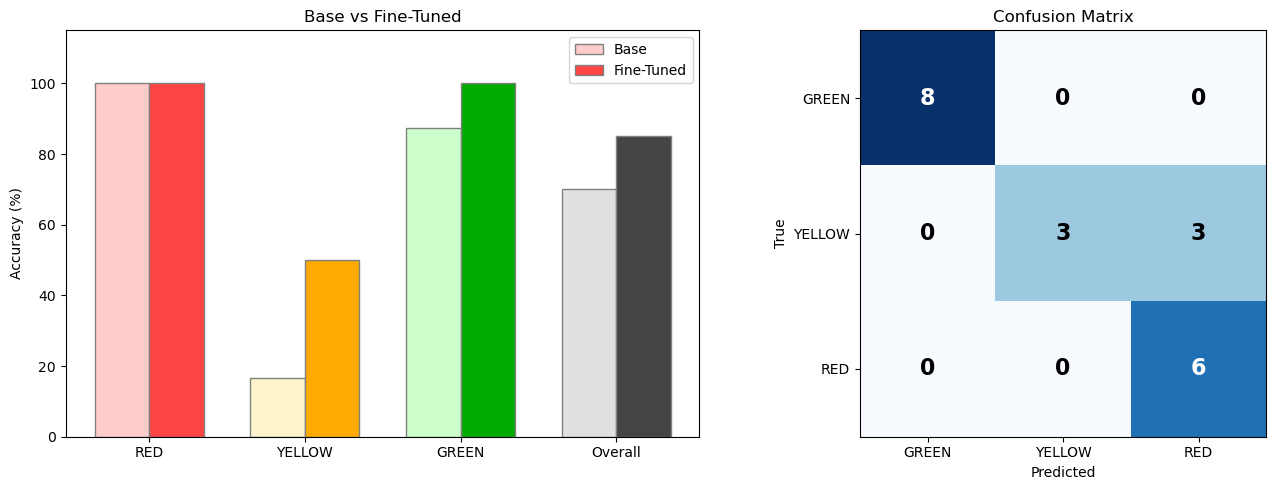

In [11]:
import matplotlib.pyplot as plt, numpy as np
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
labels = ["RED","YELLOW","GREEN","Overall"]
ba,fa = [],[]
for lv in ["RED","YELLOW","GREEN"]:
    bc=bh_l[lv]["c"]+bc_l[lv]["c"]; bt=bh_l[lv]["t"]+bc_l[lv]["t"]
    fc=fh_l[lv]["c"]+fc_l[lv]["c"]; ftt=fh_l[lv]["t"]+fc_l[lv]["t"]
    ba.append(100*bc/bt if bt else 0); fa.append(100*fc/ftt if ftt else 0)
ba.append(100*base_c/base_t); fa.append(100*ft_c/ft_t)
x=np.arange(4); w=0.35
axes[0].bar(x-w/2,ba,w,label="Base",color=["#ffcccc","#fff3cc","#ccffcc","#e0e0e0"],edgecolor="gray")
axes[0].bar(x+w/2,fa,w,label="Fine-Tuned",color=["#ff4444","#ffaa00","#00aa00","#444444"],edgecolor="gray")
axes[0].set_xticks(x); axes[0].set_xticklabels(labels); axes[0].set_ylim(0,115)
axes[0].set_ylabel("Accuracy (%)"); axes[0].set_title("Base vs Fine-Tuned"); axes[0].legend()
cm=np.zeros((3,3),dtype=int); idx={"GREEN":0,"YELLOW":1,"RED":2}
for r in fh_r+fc_r: cm[idx[r["expected"]],idx[r["predicted"]]]+=1
axes[1].imshow(cm,cmap="Blues")
for i in range(3):
    for j in range(3): axes[1].text(j,i,str(cm[i,j]),ha="center",va="center",fontsize=16,fontweight="bold",color="white" if cm[i,j]>cm.max()/2 else "black")
axes[1].set_xticks(range(3)); axes[1].set_yticks(range(3))
axes[1].set_xticklabels(["GREEN","YELLOW","RED"]); axes[1].set_yticklabels(["GREEN","YELLOW","RED"])
axes[1].set_xlabel("Predicted"); axes[1].set_ylabel("True"); axes[1].set_title("Confusion Matrix")
plt.tight_layout(); plt.savefig("cairn_results.png",dpi=150,bbox_inches="tight"); plt.show()

## Step 9: Save LoRA + Export GGUF

**This is where previous attempts failed.** The fix:
- `FastVisionModel` (not `FastLanguageModel`) handles multimodal tensor stripping
- `load_in_4bit=False` means `save_pretrained_gguf` can merge cleanly
- Known quirk ([unsloth#2346](https://github.com/unslothai/unsloth/issues/2346)): GGUF file may land in CWD instead of specified dir — we check both
- Pre-install system deps so llama.cpp builds without interactive prompts

In [12]:
# Save LoRA adapters first (always works, fast)
model.save_pretrained("cairn-e4b-triage-lora")
tokenizer.save_pretrained("cairn-e4b-triage-lora")
import os
sz = sum(os.path.getsize(os.path.join("cairn-e4b-triage-lora",f)) for f in os.listdir("cairn-e4b-triage-lora") if os.path.isfile(os.path.join("cairn-e4b-triage-lora",f)))
print(f"LoRA saved: {sz/1024**2:.0f} MB")

LoRA saved: 354 MB


In [13]:
# Pre-install system deps for llama.cpp build (avoids interactive prompt)
!sudo apt-get update -qq 2>/dev/null && sudo apt-get install -y -qq libcurl4-openssl-dev libssl-dev cmake build-essential 2>&1 | tail -1
print("System deps installed")

No VM guests are running outdated hypervisor (qemu) binaries on this host.
System deps installed


In [14]:
import glob, shutil

CWD = os.getcwd()
GGUF_DIR = "cairn-gguf"

# Record existing .gguf files so we can find new ones
existing_ggufs = set(glob.glob(f"{CWD}/**/*.gguf", recursive=True) + glob.glob(f"{CWD}/*.gguf"))

print(f"Exporting GGUF (q4_k_m) via Unsloth — ~15-20 min...")
print(f"CWD: {CWD}")
print(f"GPU: {torch.cuda.memory_allocated()/1024**3:.1f} GB")

try:
    model.save_pretrained_gguf(
        GGUF_DIR,
        tokenizer,  # For VLMs this is the processor — Unsloth handles it
        quantization_method="q4_k_m",
    )
    print("save_pretrained_gguf completed")
except Exception as e:
    print(f"save_pretrained_gguf raised: {e}")
    print("Checking if GGUF was written to CWD (known quirk)...")

# Find ALL .gguf files — check specified dir, CWD, /tmp, parent dirs
search_paths = [
    f"{GGUF_DIR}/**/*.gguf", f"{GGUF_DIR}*.gguf",
    f"{CWD}/*.gguf", f"{CWD}/**/*.gguf",
    "/tmp/*.gguf", f"{CWD}/../*.gguf",
    f"{GGUF_DIR}_gguf/**/*.gguf",  # Unsloth sometimes appends _gguf
]
all_ggufs = set()
for pattern in search_paths:
    all_ggufs.update(glob.glob(pattern, recursive=True))

# Find NEW .gguf files (not existing before export)
new_ggufs = [os.path.abspath(f) for f in all_ggufs - existing_ggufs if os.path.getsize(f) > 1024**3]

print(f"\nNew GGUF files found: {new_ggufs}")

if new_ggufs:
    gguf_path = max(new_ggufs, key=os.path.getsize)
    gguf_size = os.path.getsize(gguf_path) / 1024**3
    final_q4 = "./cairn-e4b-triage-Q4_K_M.gguf"
    if os.path.abspath(gguf_path) != os.path.abspath(final_q4):
        shutil.copy2(gguf_path, final_q4)
    print(f"GGUF: {final_q4} ({gguf_size:.1f} GB)")
else:
    final_q4 = None
    print("No GGUF found. Will push LoRA only.")

Exporting GGUF (q4_k_m) via Unsloth — ~15-20 min...
CWD: /home/ubuntu
GPU: 15.8 GB
Unsloth: Merging model weights to 16-bit format...
Found HuggingFace hub cache directory: /home/ubuntu/.cache/huggingface/hub
Checking cache directory for required files...


Unsloth: Copying 1 files from cache to `cairn-gguf`: 100%|██████████| 1/1 [00:02<00:00,  2.44s/it]


Successfully copied all 1 files from cache to `cairn-gguf`
Checking cache directory for required files...
Cache check failed: tokenizer.model not found in local cache.
Not all required files found in cache. Will proceed with downloading.


Unsloth: Merging weights into 16bit: 100%|██████████| 1/1 [00:20<00:00, 20.99s/it]


Unsloth: Merge process complete. Saved to `/home/ubuntu/cairn-gguf`
Unsloth: Converting to GGUF format...
==((====))==  Unsloth: Conversion from HF to GGUF information
   \\   /|    [0] Installing llama.cpp might take 3 minutes.
O^O/ \_/ \    [1] Converting HF to GGUF bf16 might take 3 minutes.
\        /    [2] Converting GGUF bf16 to ['q4_k_m'] might take 10 minutes each.
 "-____-"     In total, you will have to wait at least 16 minutes.

Unsloth: Installing llama.cpp. This might take 3 minutes...
Unsloth: Updating system package directories
Unsloth: Cloning llama.cpp repository...
Unsloth: Building llama.cpp - please wait 1 to 3 minutes
Unsloth: Successfully installed llama.cpp!
Unsloth: Preparing converter script...


[unsloth_zoo.llama_cpp|WARNING]Unsloth: Qwen2MoE num_experts patch target not found.


Unsloth: [1] Converting model into bf16 GGUF format.
This might take 3 minutes...
Unsloth: Initial conversion completed! Files: ['cairn-gguf_gguf/gemma-4-E4B-it.BF16.gguf', 'cairn-gguf_gguf/gemma-4-E4B-it.BF16-mmproj.gguf']
Unsloth: [2] Converting GGUF bf16 into q4_k_m. This might take 10 minutes...
Unsloth: Model files cleanup...
Unsloth: All GGUF conversions completed successfully!
Generated files: ['cairn-gguf_gguf/gemma-4-E4B-it.Q4_K_M.gguf', 'cairn-gguf_gguf/gemma-4-E4B-it.BF16-mmproj.gguf']


Unsloth: example usage for Multimodal LLMs: /home/ubuntu/.unsloth/llama.cpp/llama-mtmd-cli -m cairn-gguf_gguf/gemma-4-E4B-it.Q4_K_M.gguf --mmproj cairn-gguf_gguf/gemma-4-E4B-it.BF16-mmproj.gguf
Unsloth: load image inside llama.cpp runner: /image test_image.jpg
Unsloth: Prompt model to describe the image
Unsloth: Saved Ollama Modelfile to cairn-gguf_gguf/Modelfile
Unsloth: convert model to ollama format by running - ollama create model_name -f cairn-gguf_gguf/Modelfile
save_pretrained_gguf co

## Step 10: Push to HuggingFace

In [15]:
from huggingface_hub import HfApi
HF_USERNAME = "lightmate"
api = HfApi()

# 1. Push LoRA
print("Pushing LoRA adapters...")
model.push_to_hub(f"{HF_USERNAME}/cairn-gemma4-e4b-triage", token=HF_TOKEN)
tokenizer.push_to_hub(f"{HF_USERNAME}/cairn-gemma4-e4b-triage", token=HF_TOKEN)
print(f"LoRA: huggingface.co/{HF_USERNAME}/cairn-gemma4-e4b-triage")

# 2. Push GGUF if created
if final_q4 and os.path.exists(final_q4) and os.path.getsize(final_q4) > 1024**3:
    GGUF_REPO = f"{HF_USERNAME}/cairn-gemma4-e4b-triage-gguf"
    api.create_repo(GGUF_REPO, exist_ok=True, token=HF_TOKEN)
    print(f"\nPushing GGUF ({os.path.getsize(final_q4)/1024**3:.1f} GB)...")
    api.upload_file(path_or_fileobj=final_q4, path_in_repo="cairn-e4b-triage-Q4_K_M.gguf",
                    repo_id=GGUF_REPO, token=HF_TOKEN)
    print(f"GGUF: huggingface.co/{GGUF_REPO}")

    # Also try push_to_hub_gguf for q8_0
    print("\nPushing Q8_0 via push_to_hub_gguf...")
    try:
        model.push_to_hub_gguf(f"{HF_USERNAME}/cairn-gemma4-e4b-triage-gguf", tokenizer,
                               quantization_method="q8_0", token=HF_TOKEN)
        print("Q8_0 pushed")
    except Exception as e:
        print(f"Q8_0 push failed: {e}")
else:
    print("\nGGUF not available. LoRA adapters published.")

print("\n" + "=" * 60 + "\nAll artifacts published!\n" + "=" * 60)

Pushing LoRA adapters...


Processing Files (0 / 0): |          |  0.00B /  0.00B            
Processing Files (0 / 1):  10%|█         | 35.3MB /  339MB,  176MB/s  
Processing Files (0 / 1):  29%|██▉       | 97.6MB /  339MB,  244MB/s  
Processing Files (0 / 1):  48%|████▊     |  164MB /  339MB,  273MB/s  
Processing Files (0 / 1):  73%|███████▎  |  248MB /  339MB,  310MB/s  
Processing Files (0 / 1): 100%|█████████▉|  338MB /  339MB,  338MB/s  
Processing Files (0 / 1): 100%|█████████▉|  338MB /  339MB,  241MB/s  
Processing Files (0 / 1): 100%|█████████▉|  338MB /  339MB,  211MB/s  
Processing Files (0 / 1): 100%|█████████▉|  339MB /  339MB,  188MB/s  
Processing Files (1 / 1): 100%|██████████|  339MB /  339MB,  170MB/s  
Processing Files (1 / 1): 100%|██████████|  339MB /  339MB,  141MB/s  
New Data Upload: 100%|██████████|  331MB /  331MB,  138MB/s  


Saved model to https://huggingface.co/lightmate/cairn-gemma4-e4b-triage


Processing Files (0 / 0): |          |  0.00B /  0.00B            
Processing Files (1 / 1): 100%|██████████| 32.2MB / 32.2MB,  0.00B/s  
New Data Upload: |          |  0.00B /  0.00B,  0.00B/s  


LoRA: huggingface.co/lightmate/cairn-gemma4-e4b-triage

Pushing GGUF (5.0 GB)...


...

Unsloth: Merge process complete. Saved to `/tmp/unsloth_gguf__48am3ws`
Unsloth: Converting to GGUF format...
==((====))==  Unsloth: Conversion from HF to GGUF information
   \\   /|    [0] Installing llama.cpp might take 3 minutes.
O^O/ \_/ \    [1] Converting HF to GGUF bf16 might take 3 minutes.
\        /    [2] Converting GGUF bf16 to ['q8_0'] might take 10 minutes each.
 "-____-"     In total, you will have to wait at least 16 minutes.

Unsloth: llama.cpp found in the system. Skipping installation.
Unsloth: Preparing converter script...
Unsloth: [1] Converting model into bf16 GGUF format.
This might take 3 minutes...
Unsloth: Initial conversion completed! Files: ['/tmp/unsloth_gguf__48am3ws_gguf/gemma-4-E4B-it.BF16.gguf', '/tmp/unsloth_gguf__48am3ws_gguf/gemma-4-E4B-it.BF16-mmproj.gguf']
Unsloth: [2] Converting GGUF bf16 into q8_0. This might take 10 minutes...
Unsloth: Model files cleanup...
Unsloth: All GGUF conversions completed successfully!
Generated files: ['/tmp/unsloth_ggu

Processing Files (0 / 0): |          |  0.00B /  0.00B            
Processing Files (0 / 1):  48%|████▊     | 3.82GB / 8.03GB,  781MB/s  
Processing Files (0 / 1):  49%|████▉     | 3.97GB / 8.03GB,  779MB/s  
Processing Files (0 / 1):  51%|█████     | 4.11GB / 8.03GB,  776MB/s  
Processing Files (0 / 1):  53%|█████▎    | 4.25GB / 8.03GB,  774MB/s  
Processing Files (0 / 1):  55%|█████▍    | 4.41GB / 8.03GB,  774MB/s  
Processing Files (0 / 1):  56%|█████▌    | 4.50GB / 8.03GB,  763MB/s  
Processing Files (0 / 1):  58%|█████▊    | 4.66GB / 8.03GB,  766MB/s  
Processing Files (0 / 1):  60%|██████    | 4.83GB / 8.03GB,  768MB/s  
Processing Files (0 / 1):  62%|██████▏   | 5.00GB / 8.03GB,  770MB/s  
Processing Files (0 / 1):  64%|██████▍   | 5.14GB / 8.03GB,  768MB/s  
Processing Files (0 / 1):  66%|██████▌   | 5.28GB / 8.03GB,  766MB/s  
Processing Files (0 / 1):  67%|██████▋   | 5.41GB / 8.03GB,  763MB/s  
Processing Files (0 / 1):  70%|██████▉   | 5.58GB / 8.03GB,  765MB/s  
Processing

Uploading gemma-4-E4B-it.BF16-mmproj.gguf...


Processing Files (0 / 0): |          |  0.00B /  0.00B            
Processing Files (0 / 1): 100%|█████████▉|  990MB /  992MB,  619MB/s  
Processing Files (0 / 1): 100%|█████████▉|  991MB /  992MB,  550MB/s  
Processing Files (1 / 1): 100%|██████████|  992MB /  992MB,  451MB/s  
Processing Files (1 / 1): 100%|██████████|  992MB /  992MB,  413MB/s  
New Data Upload: 100%|██████████| 39.5MB / 39.5MB, 16.4MB/s  


Uploading config.json...
Uploading Ollama Modelfile...
Unsloth: Successfully uploaded GGUF to https://huggingface.co/lightmate/cairn-gemma4-e4b-triage-gguf
Unsloth: Cleaning up temporary files...
Q8_0 pushed

All artifacts published!


## Step 11: Verify from HuggingFace

Load the LoRA back from HF on a fresh model and test one case.

In [16]:
# Verification: load LoRA from HF and test
del model
gc.collect(); torch.cuda.empty_cache()

model_v, tok_v = FastVisionModel.from_pretrained(
    model_name="lightmate/cairn-gemma4-e4b-triage",
    max_seq_length=2048, load_in_4bit=True, token=HF_TOKEN,
)
FastVisionModel.for_inference(model_v)
msgs = [{"role":"user","content":[{"type":"text","text":"Triage: 25yo, paper cut, bleeding stopped."}]}]
inputs = tok_v.apply_chat_template(msgs, tokenize=True, return_tensors="pt", add_generation_prompt=True).to(model_v.device)
with torch.no_grad():
    out = model_v.generate(input_ids=inputs, max_new_tokens=128, temperature=0.1)
resp = tok_v.decode(out[0][inputs.shape[-1]:], skip_special_tokens=True)
print("Verification response:")
print(resp)
print(f"\nExpected: GREEN. Got: {extract_triage_level(resp)}")

==((====))==  Unsloth 2026.4.6: Fast Gemma4 patching. Transformers: 5.5.0.
   \\   /|    NVIDIA GH200 480GB. Num GPUs = 1. Max memory: 94.5 GB. Platform: Linux.
O^O/ \_/ \    Torch: 2.10.0+cu128. CUDA: 9.0. CUDA Toolkit: 12.8. Triton: 3.6.0
\        /    Bfloat16 = TRUE. FA [Xformers = None. FA2 = False]
 "-____-"     Free license: http://github.com/unslothai/unsloth
Unsloth: Fast downloading is enabled - ignore downloading bars which are red colored!


Loading weights: 100%|██████████| 2130/2130 [00:01<00:00, 1385.61it/s]


Verification response:
**Triage Level: RED (Immediate Life Threat) - NO, YELLOW (Urgent) - YES, or GREEN (Non-Urgent) - YES**

**Assessment:**

* **Green (Non-Urgent):** This is the most appropriate classification. A paper cut with bleeding that has already stopped is a minor wound that does not require emergency medical intervention.
* **Yellow (Urgent):** This might be considered if the wound was deep, gaping, or showed signs of infection, but since the bleeding has stopped, it's less likely to be an urgent medical issue.
* **Red (Immediate

Expected: GREEN. Got: RED


## Deploy: Ollama

### If GGUF was exported:
```bash
huggingface-cli download lightmate/cairn-gemma4-e4b-triage-gguf --include "*.gguf" --local-dir ./cairn-gguf
cat > Modelfile << 'EOF'
FROM ./cairn-gguf/cairn-e4b-triage-Q4_K_M.gguf
PARAMETER temperature 0.1
PARAMETER num_ctx 4096
SYSTEM "You are Cairn, an offline medical triage assistant. Provide: 1) Triage level (RED/YELLOW/GREEN), 2) Assessment, 3) Recommendations, 4) Confidence."
EOF
ollama create cairn-e4b-triage -f Modelfile
ollama run cairn-e4b-triage "Triage: paper cut, bleeding stopped."
```

---

**[Cairn](https://github.com/rkstu/cairn)** | [Unsloth](https://github.com/unslothai/unsloth) | [Gemma 4](https://ai.google.dev/gemma/docs)